# 21 — Disease Prevalence Analysis

**Purpose**: Characterize the most commonly occurring diseases across the full AI-READI cohort and stratify by (1) diabetes severity group, (2) age band, and (3) all 16 group × age intersections. Establishes a comorbidity baseline for the cohort — a foundational descriptive layer for any downstream modeling or clinical paper.

**Data source**: Self-reported medical history (`mhoccur_*` items) from `observation.csv`. Each item is a binary flag (1 = condition present, 0 = absent). Prevalence = % of patients in each subgroup reporting that condition (NaN suppressed for cells with n < 5).

**Self-contained**: Loads directly from Azure — no dependency on prior notebook outputs.

**Inputs**:
- Azure `{STUDY_ID}/dataset/participants.tsv` — study group labels
- Azure `{STUDY_ID}/dataset/clinical_data/person.csv` — year of birth → age
- Azure `{STUDY_ID}/dataset/clinical_data/observation.csv` — mhoccur survey items (~108 MB)

**Outputs**:
- `21_overall_top_diseases.csv` — ranked prevalence for full cohort
- `21_prevalence_by_study_group.csv` — disease × study group wide table
- `21_prevalence_by_age_group.csv` — disease × age band wide table
- `21_heatmap_16_cells.csv` — full 16-cell prevalence matrix
- `21_01_overall_top_diseases.png` — ranked bar chart, full cohort
- `21_02_by_study_group.png` — 4-panel bar chart by diabetes stage
- `21_03_by_age_group.png` — 4-panel bar chart by age band
- `21_04_heatmap_group_x_age.png` — 20 diseases × 16 group+age combinations
- `21_05_heatmap_faceted_by_group.png` — same data, one panel per study group

---

**Table of Contents**
1. Environment Setup
2. Azure Connection & Data Load
3. Parse mhoccur Items & Build Master DataFrame
4. Analysis 1 — Overall Top Diseases
5. Analysis 2 — By Study Group
6. Analysis 3 — By Age Group
7. Analysis 4 — Study Group × Age Band Heatmaps
8. Summary Tables & Export
9. Key Findings

---

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

for pkg in ['azure-storage-blob', 'seaborn', 'scipy', 'python-dotenv']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, re, warnings, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from io import StringIO

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_STR_MAP = {
    'healthy': 0, 'prediabetes': 1, 'pre-diabetes': 1, 'pre_diabetes': 1,
    'oral medication': 2, 'oral_medication': 2, 'non-insulin': 2,
    'insulin': 3, 'insulin-dependent': 3,
    'pre_diabetes_lifestyle_controlled': 1,
    'oral_medication_and_or_non_insulin_injectable_medication_controlled': 2,
    'insulin_dependent': 3,
}

# Age bins: right=False means [40,55) → '40–54', [55,70) → '55–69', etc.
AGE_BINS   = [40, 55, 70, 80, 120]
AGE_LABELS = ['40–54', '55–69', '70–79', '80+']
AGE_ORDER  = AGE_LABELS

STUDY_ID = '1438dd73-c4cb-48b8-8fa8-c858771207c3'
TOP_N    = 20   # diseases shown in ranked bar charts

print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Azure Connection & Data Load ──────────────────────────────
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    print('Paste your Azure CONNECTION_STRING when prompted:')
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME = 'aireadi-container'
    STUDY_ID       = '1438dd73-c4cb-48b8-8fa8-c858771207c3'
    print(f'Container : {CONTAINER_NAME}')
    print(f'Study ID  : {STUDY_ID}')
else:
    # VSCode / Cursor: cwd = project root.  Classic Jupyter: cwd = notebooks/
    _cwd = Path.cwd()
    if (_cwd / 'config' / 'azure_config.py').exists():
        repo_root = str(_cwd)
    elif (_cwd.parent / 'config' / 'azure_config.py').exists():
        repo_root = str(_cwd.parent)
    else:
        repo_root = str(_cwd)

    # Load .env directly — avoids stale module cache if .env was changed mid-session
    _env_path = Path(repo_root) / '.env'
    load_dotenv(_env_path, override=True)

    CONNECTION_STRING = os.getenv('AZURE_STORAGE_CONNECTION_STRING', '')
    CONTAINER_NAME    = os.getenv('AZURE_CONTAINER_NAME', 'aireadi-container')
    STUDY_ID          = os.getenv('AZURE_STUDY_ID', STUDY_ID)


    print(f'.env path : {_env_path}  (found={_env_path.exists()})')
    print(f'repo_root : {repo_root}')
    print(f'Container : {CONTAINER_NAME}')
    print(f'Study ID  : {STUDY_ID}')

    if not CONNECTION_STRING:
        raise ValueError('AZURE_STORAGE_CONNECTION_STRING is empty — check your .env file')

blob_svc  = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container = blob_svc.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    """Stream a CSV/TSV directly from Azure Blob into a DataFrame."""
    bc   = container.get_blob_client(blob_path)
    data = bc.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

# ── Load participants (study group labels) ────────────────────────
print('\nLoading participants.tsv ...')
participants = load_blob_csv(f'{STUDY_ID}/dataset/participants.tsv', sep='\t')
sg_col = next((c for c in participants.columns if 'study' in c.lower()), None)
print(f'  Study group column: "{sg_col}"')
participants['study_group_code']  = (participants[sg_col].str.lower()
                                     .str.strip().map(STUDY_GROUP_STR_MAP))
participants['study_group_label'] = participants['study_group_code'].map(STUDY_GROUP_MAP)
participants['study_group_label'] = pd.Categorical(
    participants['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
print(f'  {len(participants):,} participants')
print(participants['study_group_label'].value_counts().sort_index().to_string())

# ── Load person table (year_of_birth → age) ────────────────────────
print('\nLoading person.csv ...')
person = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/person.csv',
                       usecols=['person_id', 'year_of_birth'])
person['age'] = 2024 - person['year_of_birth']
person['age_group'] = pd.cut(person['age'], bins=AGE_BINS, labels=AGE_LABELS, right=False)
person['age_group'] = pd.Categorical(person['age_group'], categories=AGE_ORDER, ordered=True)
print(f'  {len(person):,} persons  |  age range: {person["age"].min()}–{person["age"].max()}')
print(person['age_group'].value_counts().sort_index().to_string())

# ── Load observation table (~108 MB — mhoccur items live here) ────
print('\nLoading observation.csv (~108 MB) ...')
obs_raw = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/observation.csv')
print(f'  {len(obs_raw):,} rows × {obs_raw.shape[1]} cols')

.env path : /Users/evanlee/Desktop/ucsf-tech-aireadi/.env  (found=True)
repo_root : /Users/evanlee/Desktop/ucsf-tech-aireadi
Container : aireadi-container
Study ID  : 1438dd73-c4cb-48b8-8fa8-c858771207c3

Loading participants.tsv ...
  Study group column: "study_group"
  2,280 participants
study_group_label
Healthy     776
Pre-DM      560
Oral Med    686
Insulin     258

Loading person.csv ...
  2,280 persons  |  age range: 41–94
age_group
40–54     688
55–69    1015
70–79     458
80+       119

Loading observation.csv (~108 MB) ...
  707,126 rows × 22 cols


In [3]:
# ── 3. Parse mhoccur Items & Build Master DataFrame ───────────────

# Extract item_key from source value  (e.g. "mhoccur_htn, Do you have hypertension?" → "mhoccur_htn")
obs_raw['item_key'] = (obs_raw['observation_source_value']
                       .astype(str).str.split(',', n=1).str[0]
                       .str.strip().str.lower())
obs_raw['value_clean'] = pd.to_numeric(obs_raw['value_as_number'], errors='coerce')
obs_raw.loc[obs_raw['value_clean'] == 99, 'value_clean'] = np.nan  # sentinel → missing

# Keep only mhoccur rows
mh_obs = obs_raw[obs_raw['item_key'].str.startswith('mhoccur', na=False)].copy()
print(f'mhoccur rows: {len(mh_obs):,}  |  unique items: {mh_obs["item_key"].nunique()}')

# Build human-readable label map from the description part of source_value
def clean_label(s):
    if not isinstance(s, str): return str(s)
    s = re.sub(
        r'^(Do you (currently )?have |Have you (ever )?had |'
        r'Have you been (told by a doctor |diagnosed )|'
        r'You have been diagnosed with )',
        '', s, flags=re.IGNORECASE).strip()
    s = s.rstrip('?').strip()
    return s[:1].upper() + s[1:] if s else s

label_map_raw = (mh_obs[['item_key', 'observation_source_value']]
                 .drop_duplicates('item_key')
                 .assign(desc=lambda d: d['observation_source_value']
                                         .str.split(',', n=1).str[1]
                                         .str.strip()))
label_map = dict(zip(label_map_raw['item_key'],
                     label_map_raw['desc'].apply(clean_label)))

print('\nSample label mappings (first 10):')
for k, v in list(label_map.items())[:10]:
    print(f'  {k:40s} → {v}')

# Pivot: one row per patient, one column per disease (binary 0/1)
mh_wide = (mh_obs[['person_id', 'item_key', 'value_clean']]
           .pivot_table(index='person_id', columns='item_key',
                        values='value_clean', aggfunc='first')
           .clip(upper=1))  # binarize

# Drop the fall-count item (it's continuous, not a disease flag)
disease_cols = [c for c in mh_wide.columns if 'fallot' not in c]
mh_wide = mh_wide[disease_cols]
print(f'\nmh_wide shape: {mh_wide.shape[0]:,} patients × {mh_wide.shape[1]} diseases')

# ── Merge everything into one flat DataFrame ──────────────────────
base = (participants[['person_id', 'study_group_code', 'study_group_label']]
        .merge(person[['person_id', 'age', 'age_group']], on='person_id', how='left'))

df = base.merge(mh_wide, left_on='person_id', right_index=True, how='left')
df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
df['age_group'] = pd.Categorical(
    df['age_group'], categories=AGE_ORDER, ordered=True)

print(f'\nFinal df: {df.shape[0]:,} participants × {df.shape[1]} columns')
print('\nGroup × Age counts:')
print(df.groupby(['study_group_label', 'age_group'], observed=True).size()
        .unstack(fill_value=0).to_string())

mhoccur rows: 66,486  |  unique items: 30

Sample label mappings (first 10):
  mhoccur_mi                               → Heart attack
  mhoccur_cvdot                            → Other heart issues (Examples: pace
  mhoccur_strk                             → Stroke
  mhoccur_clsh                             → High blood cholesterol
  mhoccur_hbp                              → High blood pressure
  mhoccur_ua                               → Urinary problems (Examples: urinary t
  mhoccur_ear                              → Hearing impairment
  mhoccur_pdr                              → Diabetic retinopathy (in one or both
  mhoccur_circ                             → Circulation problems (Examples: art
  mhoccur_lbp                              → Low blood pressure

mh_wide shape: 2,280 patients × 29 diseases

Final df: 2,280 participants × 34 columns

Group × Age counts:
age_group          40–54  55–69  70–79  80+
study_group_label                          
Healthy              260    3

---
## 4. Analysis 1 — Overall Top Diseases

Ranks all 29 conditions by prevalence across the full 2,280-person cohort.
Shows the dominant comorbidity profile regardless of diabetes stage or age.

In [4]:
# ── Helper functions ──────────────────────────────────────────────

def prevalence_series(data, cols=None, top_n=TOP_N):
    """Return top_n diseases sorted by prevalence (%) for a subset DataFrame."""
    if cols is None:
        cols = disease_cols
    pct = data[cols].mean(skipna=True) * 100
    pct.index = [label_map.get(c, c) for c in pct.index]
    return pct.sort_values(ascending=False).head(top_n)

def plot_horiz_bar(ax, series, title, color, n_total):
    """Draw a horizontal bar chart of disease prevalence on ax."""
    vals   = series.values[::-1]
    labels = series.index[::-1]
    bars = ax.barh(labels, vals, color=color, edgecolor='white', height=0.7)
    ax.set_xlabel('Prevalence (%)', fontsize=9)
    ax.set_title(f'{title}\n(n={n_total:,})', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
    for bar, val in zip(bars, vals):
        ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=8)
    ax.set_xlim(0, min(100, series.max() * 1.30 + 2))
    ax.tick_params(axis='y', labelsize=9)

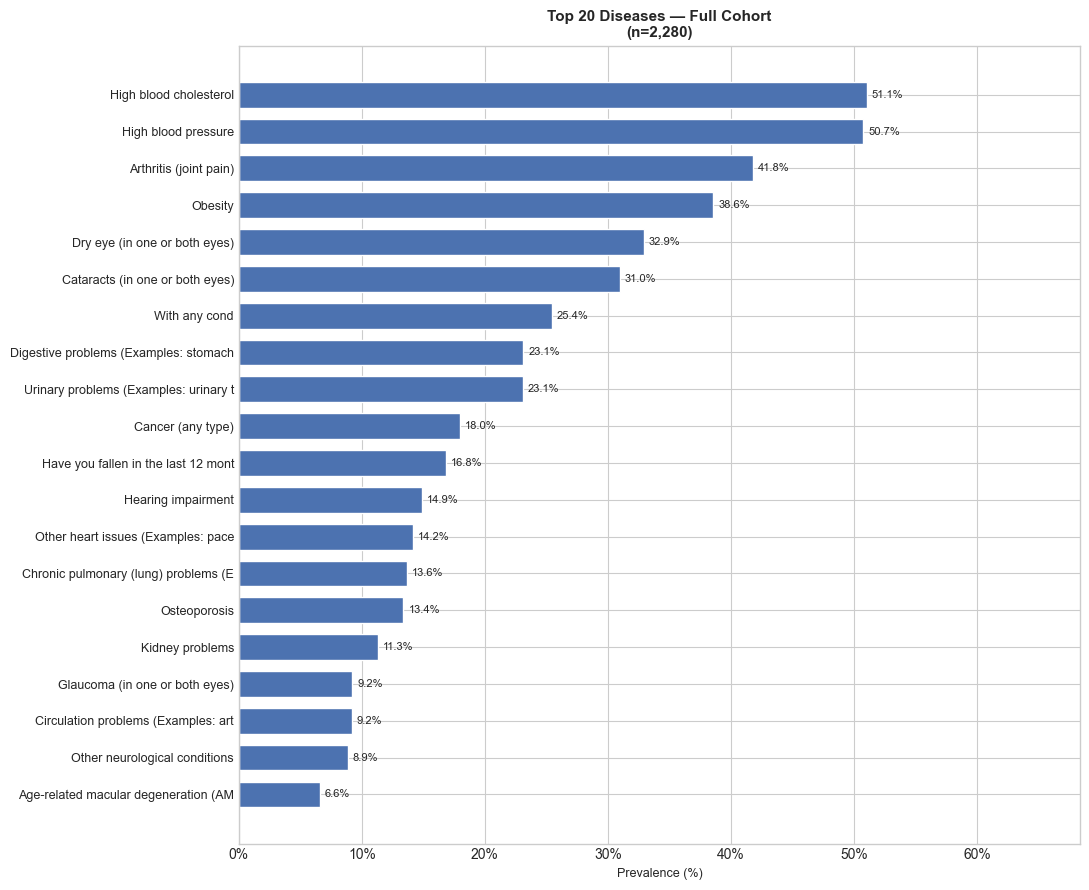


Rank  Disease                                               Prevalence
────────────────────────────────────────────────────────────────────────
   1. High blood cholesterol                                     51.1%
   2. High blood pressure                                        50.7%
   3. Arthritis (joint pain)                                     41.8%
   4. Obesity                                                    38.6%
   5. Dry eye (in one or both eyes)                              32.9%
   6. Cataracts (in one or both eyes)                            31.0%
   7. With any cond                                              25.4%
   8. Digestive problems (Examples: stomach                      23.1%
   9. Urinary problems (Examples: urinary t                      23.1%
  10. Cancer (any type)                                          18.0%
  11. Have you fallen in the last 12 mont                        16.8%
  12. Hearing impairment                                         14.9%
  1

In [5]:
# ── Analysis 1: Overall Top Diseases ─────────────────────────────
top_overall = prevalence_series(df, top_n=TOP_N)

fig, ax = plt.subplots(figsize=(11, 9))
plot_horiz_bar(ax, top_overall, f'Top {TOP_N} Diseases — Full Cohort', '#4C72B0', len(df))
plt.tight_layout()
plt.show()

print(f'\n{"Rank":>4}  {"Disease":<52}  {"Prevalence":>10}')
print('─' * 72)
for rank, (disease, pct) in enumerate(top_overall.items(), 1):
    print(f'{rank:>4}. {disease:<52}  {pct:>9.1f}%')

---
## 5. Analysis 2 — By Study Group

Separate top-15 ranking for each diabetes severity group (Healthy / Pre-DM / Oral Med / Insulin).
Reveals which conditions are universal vs diabetes-specific.

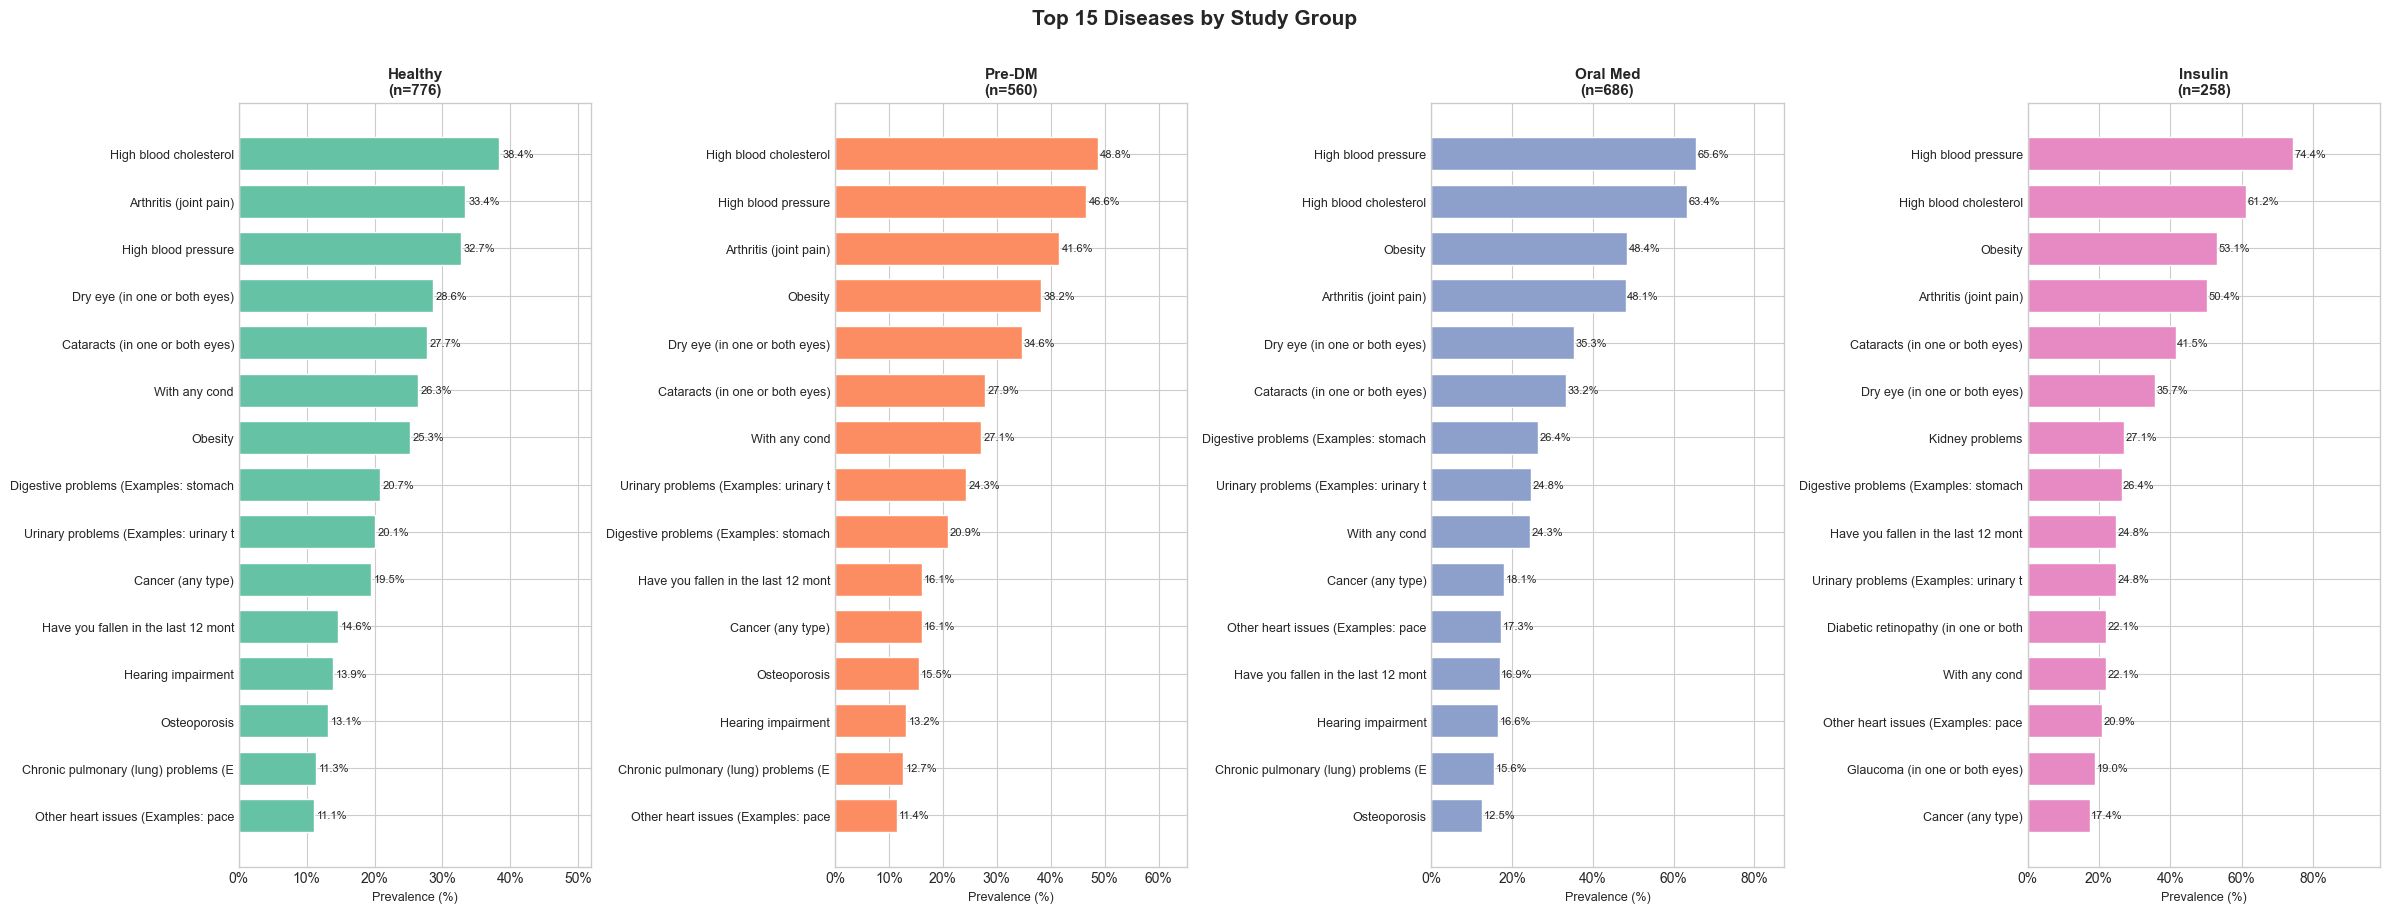


── Healthy (n=776) ──
   1. High blood cholesterol                              38.4%
   2. Arthritis (joint pain)                              33.4%
   3. High blood pressure                                 32.7%
   4. Dry eye (in one or both eyes)                       28.6%
   5. Cataracts (in one or both eyes)                     27.7%
   6. With any cond                                       26.3%
   7. Obesity                                             25.3%
   8. Digestive problems (Examples: stomach               20.7%
   9. Urinary problems (Examples: urinary t               20.1%
  10. Cancer (any type)                                   19.5%

── Pre-DM (n=560) ──
   1. High blood cholesterol                              48.8%
   2. High blood pressure                                 46.6%
   3. Arthritis (joint pain)                              41.6%
   4. Obesity                                             38.2%
   5. Dry eye (in one or both eyes)                       3

In [6]:
# ── Analysis 2: Top Diseases by Study Group ───────────────────────
palette_sg = sns.color_palette('Set2', 4)

fig, axes = plt.subplots(1, 4, figsize=(24, 9), sharey=False)
fig.suptitle('Top 15 Diseases by Study Group', fontsize=15, fontweight='bold', y=1.01)

for ax, grp, color in zip(axes, STUDY_GROUP_ORDER, palette_sg):
    sub = df[df['study_group_label'] == grp]
    top = prevalence_series(sub, top_n=15)
    plot_horiz_bar(ax, top, grp, color, len(sub))

plt.tight_layout()
plt.show()

# Print ranked tables side-by-side
for grp in STUDY_GROUP_ORDER:
    sub = df[df['study_group_label'] == grp]
    top = prevalence_series(sub, top_n=10)
    print(f'\n── {grp} (n={len(sub):,}) ──')
    for rank, (disease, pct) in enumerate(top.items(), 1):
        print(f'  {rank:2}. {disease:<50}  {pct:.1f}%')

---
## 6. Analysis 3 — By Age Group

Separate top-15 ranking for each age band (40–54 / 55–69 / 70–79 / 80+).
Isolates pure aging effects from diabetes-driven comorbidities.

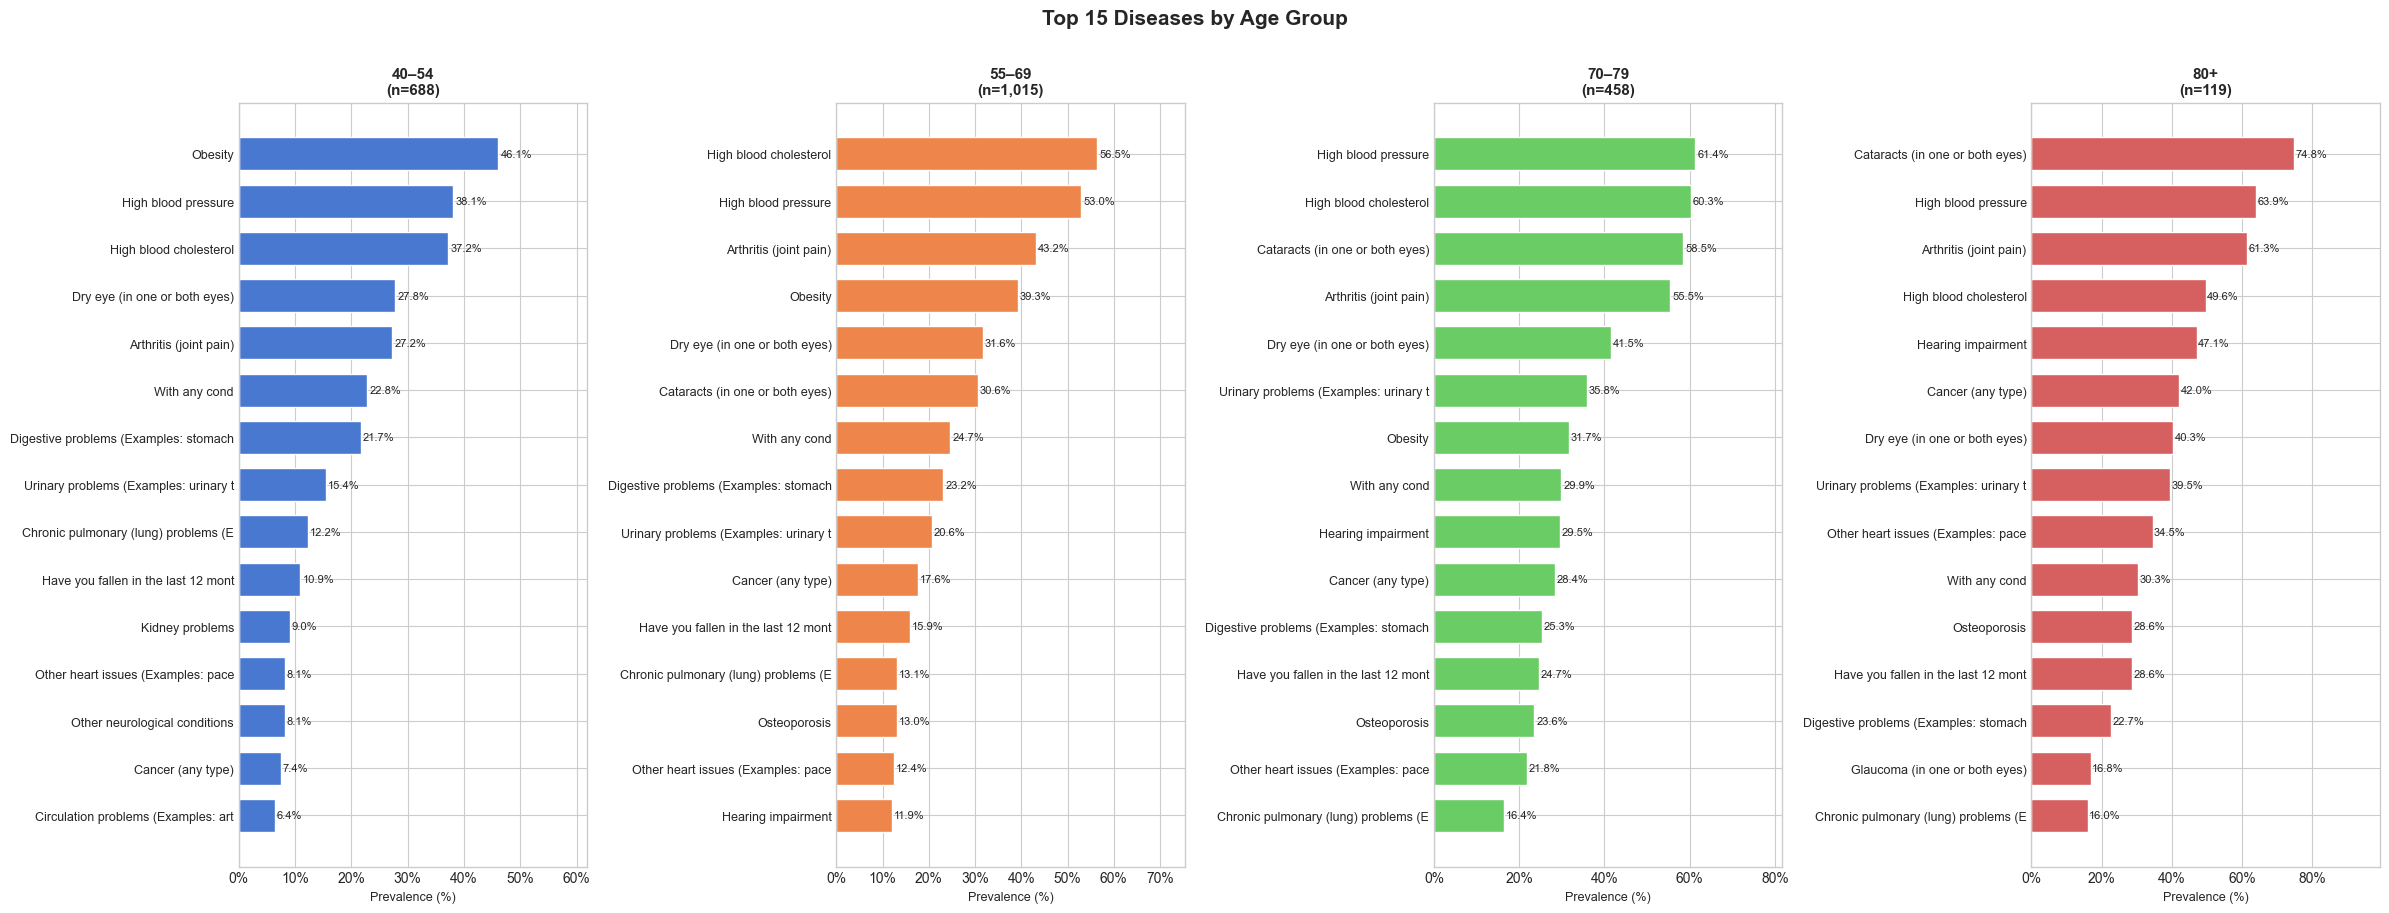


── Age 40–54 (n=688) ──
   1. Obesity                                             46.1%
   2. High blood pressure                                 38.1%
   3. High blood cholesterol                              37.2%
   4. Dry eye (in one or both eyes)                       27.8%
   5. Arthritis (joint pain)                              27.2%
   6. With any cond                                       22.8%
   7. Digestive problems (Examples: stomach               21.7%
   8. Urinary problems (Examples: urinary t               15.4%
   9. Chronic pulmonary (lung) problems (E                12.2%
  10. Have you fallen in the last 12 mont                 10.9%

── Age 55–69 (n=1,015) ──
   1. High blood cholesterol                              56.5%
   2. High blood pressure                                 53.0%
   3. Arthritis (joint pain)                              43.2%
   4. Obesity                                             39.3%
   5. Dry eye (in one or both eyes)                 

In [7]:
# ── Analysis 3: Top Diseases by Age Group ────────────────────────
palette_age = sns.color_palette('muted', 4)

fig, axes = plt.subplots(1, 4, figsize=(24, 9), sharey=False)
fig.suptitle('Top 15 Diseases by Age Group', fontsize=15, fontweight='bold', y=1.01)

for ax, age_grp, color in zip(axes, AGE_ORDER, palette_age):
    sub = df[df['age_group'] == age_grp]
    top = prevalence_series(sub, top_n=15)
    plot_horiz_bar(ax, top, age_grp, color, len(sub))

plt.tight_layout()
plt.show()

for age_grp in AGE_ORDER:
    sub = df[df['age_group'] == age_grp]
    top = prevalence_series(sub, top_n=10)
    print(f'\n── Age {age_grp} (n={len(sub):,}) ──')
    for rank, (disease, pct) in enumerate(top.items(), 1):
        print(f'  {rank:2}. {disease:<50}  {pct:.1f}%')

---
## 7. Analysis 4 — Study Group × Age Band Heatmaps

Two complementary views of all 16 group × age intersections:
- **Heatmap A**: 20 diseases × 16 combinations in a single grid — best for spotting overall patterns
- **Heatmap B**: same data split into 4 panels (one per study group) — best for within-group age trajectories

Cells with n < 5 are suppressed (shown as blank).

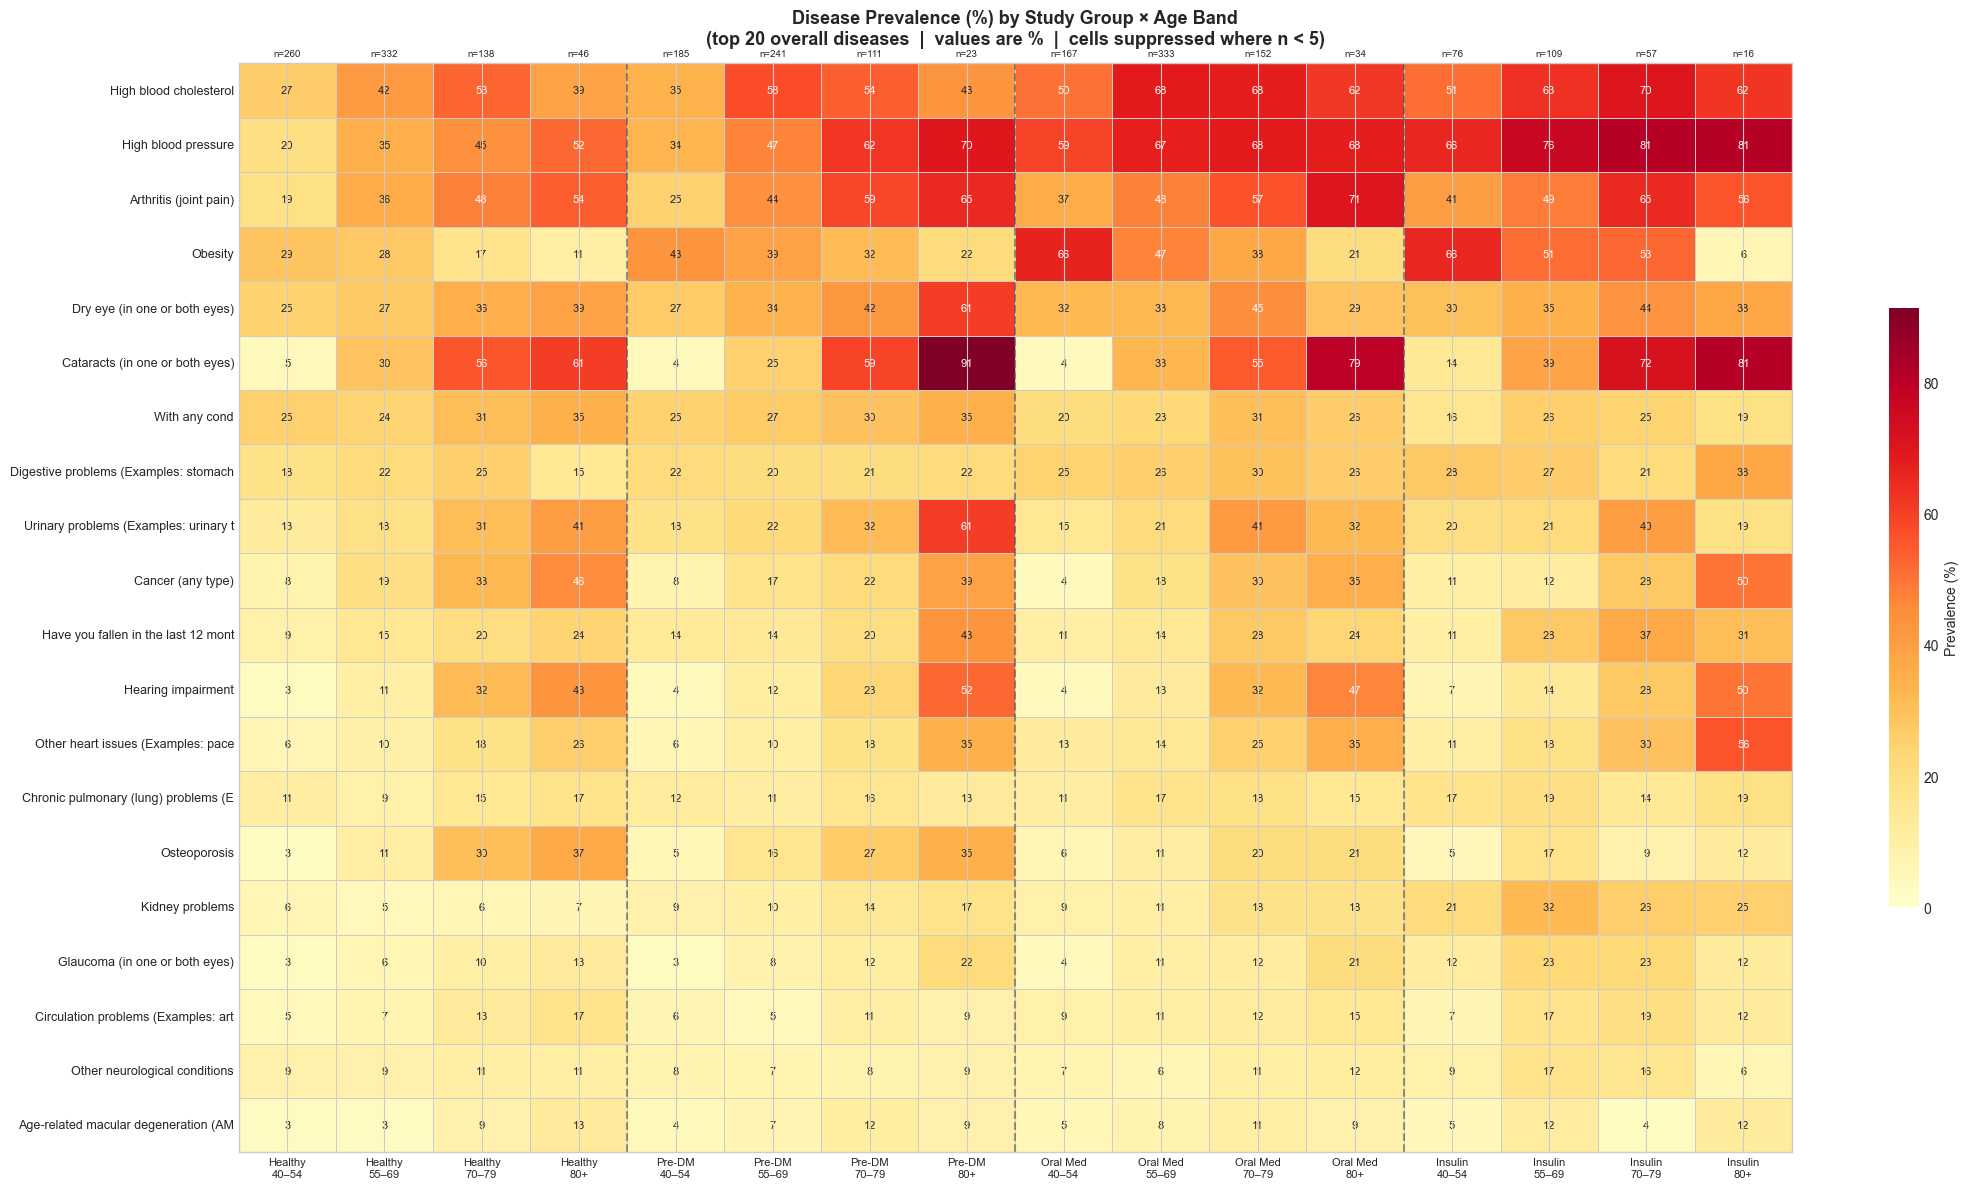

In [8]:
# ── Analysis 4: Study Group × Age Group Heatmap (16 cells) ────────
# Use the top-20 overall diseases as the row set.

top_overall_labels = top_overall.index.tolist()
# Map readable labels back to column keys for subsetting df
label_to_key = {v: k for k, v in label_map.items()}
top_keys = [label_to_key[lbl] for lbl in top_overall_labels if lbl in label_to_key]

# Build prevalence table: disease × 16-combo
records = []
for sg in STUDY_GROUP_ORDER:
    for ag in AGE_ORDER:
        sub = df[(df['study_group_label'] == sg) & (df['age_group'] == ag)]
        n   = len(sub)
        for key in top_keys:
            label = label_map.get(key, key)
            # Suppress cells with fewer than 5 patients to avoid misleading %
            pct   = sub[key].mean(skipna=True) * 100 if n >= 5 else np.nan
            records.append({'study_group': sg, 'age_group': ag,
                            'disease': label, 'prevalence': pct, 'n': n})

heat_df = pd.DataFrame(records)
heat_df['combo'] = heat_df['study_group'] + '\n' + heat_df['age_group']
combo_order = [f'{sg}\n{ag}' for sg in STUDY_GROUP_ORDER for ag in AGE_ORDER]

pivot = (heat_df
         .pivot_table(index='disease', columns='combo', values='prevalence', aggfunc='first')
         .reindex(columns=combo_order)
         .reindex(index=top_overall_labels))

# N per cell (for annotation on the column headers)
n_per_cell = (heat_df.drop_duplicates(['study_group', 'age_group'])
              .assign(combo=lambda d: d['study_group'] + '\n' + d['age_group'])
              .set_index('combo')['n']
              .reindex(combo_order))

# ── Draw heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 12))

sns.heatmap(
    pivot, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, linecolor='#cccccc',
    annot_kws={'size': 8}, ax=ax,
    cbar_kws={'label': 'Prevalence (%)', 'shrink': 0.55},
    vmin=0, vmax=pivot.max().max()
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title(
    'Disease Prevalence (%) by Study Group × Age Band\n'
    '(top 20 overall diseases  |  values are %  |  cells suppressed where n < 5)',
    fontsize=13, fontweight='bold', pad=14
)
ax.tick_params(axis='x', labelsize=8, rotation=0)
ax.tick_params(axis='y', labelsize=9)

# Add sample-size row along the top x-axis
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(np.arange(len(combo_order)) + 0.5)
ax2.set_xticklabels(
    [f'n={int(n_per_cell[c])}' if pd.notna(n_per_cell.get(c)) else '' for c in combo_order],
    fontsize=7
)
ax2.tick_params(top=False)

# Draw vertical separator lines between study groups (every 4 age bands)
for x in [4, 8, 12]:
    ax.axvline(x, color='#555555', linewidth=1.5, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

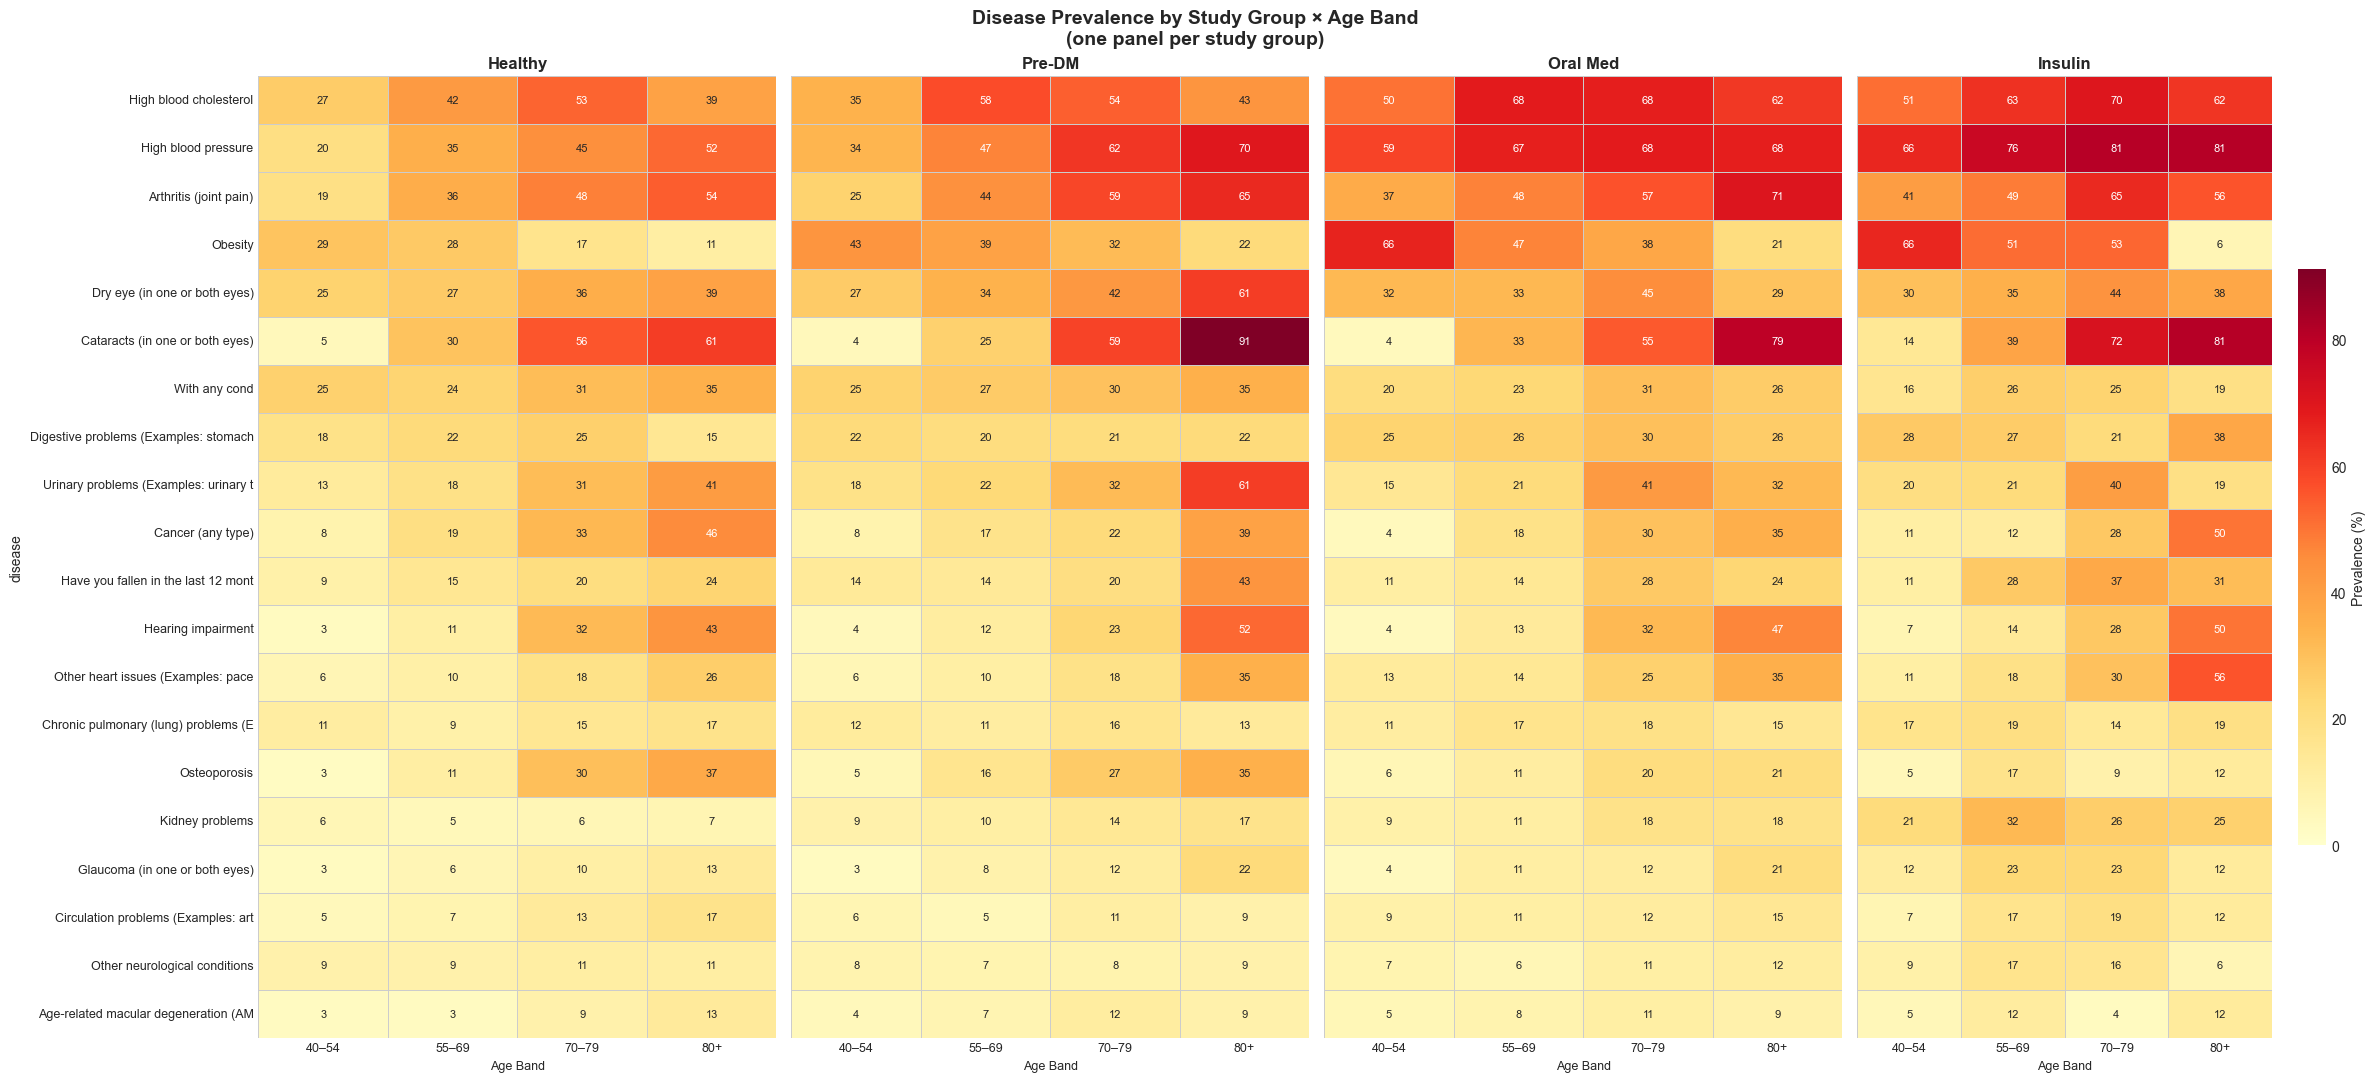

In [9]:
# ── Bonus: Same heatmap with study groups on rows instead of columns ──
# Useful for a different visual angle on the same data.

fig, axes = plt.subplots(1, 4, figsize=(24, 11), sharey=True)
fig.suptitle('Disease Prevalence by Study Group × Age Band\n(one panel per study group)',
             fontsize=14, fontweight='bold')

for ax, sg, color in zip(axes, STUDY_GROUP_ORDER, sns.color_palette('Set2', 4)):
    combo_cols = [f'{sg}\n{ag}' for ag in AGE_ORDER]
    sub_pivot  = pivot[combo_cols].copy()
    sub_pivot.columns = AGE_ORDER

    mask = sub_pivot.isna()
    sns.heatmap(
        sub_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
        linewidths=0.4, linecolor='#cccccc',
        annot_kws={'size': 8}, ax=ax, mask=mask,
        vmin=0, vmax=pivot.max().max(),
        cbar=ax is axes[-1],
        cbar_kws={'label': 'Prevalence (%)', 'shrink': 0.6}
    )
    ax.set_title(sg, fontsize=12, fontweight='bold')
    ax.set_xlabel('Age Band', fontsize=9)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    if ax is not axes[0]:
        ax.set_ylabel('')

plt.tight_layout()
plt.show()

---
## 8. Summary Tables & Export

In [10]:
# ── 8. Summary Tables & Export ───────────────────────────────

# Overall ranking
overall_tbl = top_overall.reset_index()
overall_tbl.columns = ['disease', 'prevalence_pct']
overall_tbl.index = range(1, len(overall_tbl) + 1)
overall_tbl['prevalence_pct'] = overall_tbl['prevalence_pct'].round(1)
print('=== OVERALL TOP DISEASES ===')
print(overall_tbl.to_string())

# Wide table: disease × study group
sg_wide = pd.DataFrame(
    {sg: prevalence_series(df[df['study_group_label'] == sg])
     for sg in STUDY_GROUP_ORDER}
).round(1)
print('\n=== BY STUDY GROUP (top 20, %) ===')
print(sg_wide.to_string())

# Wide table: disease × age group
age_wide = pd.DataFrame(
    {ag: prevalence_series(df[df['age_group'] == ag])
     for ag in AGE_ORDER}
).round(1)
print('\n=== BY AGE GROUP (top 20, %) ===')
print(age_wide.to_string())

# 16-cell heatmap table
print('\n=== STUDY GROUP × AGE BAND (top 20, %) ===')
print(pivot.round(1).to_string())

=== OVERALL TOP DISEASES ===
                                  disease  prevalence_pct
1                  High blood cholesterol           51.10
2                     High blood pressure           50.70
3                  Arthritis (joint pain)           41.80
4                                 Obesity           38.60
5           Dry eye (in one or both eyes)           32.90
6         Cataracts (in one or both eyes)           31.00
7                           With any cond           25.40
8   Digestive problems (Examples: stomach           23.10
9   Urinary problems (Examples: urinary t           23.10
10                      Cancer (any type)           18.00
11    Have you fallen in the last 12 mont           16.80
12                     Hearing impairment           14.90
13     Other heart issues (Examples: pace           14.20
14   Chronic pulmonary (lung) problems (E           13.60
15                           Osteoporosis           13.40
16                        Kidney problems  

---
## 9. Key Findings

- **Cardiometabolic triad dominates the cohort**: High cholesterol (51.1%), hypertension (50.7%), and obesity (38.6%) are the three most prevalent conditions — present at high rates across all diabetes stages and age groups.

- **Diabetes severity drives a stepwise comorbidity escalation**: Hypertension rises from 32.7% (Healthy) → 46.6% (Pre-DM) → 65.6% (Oral Med) → 74.4% (Insulin). The same gradient holds for cholesterol, obesity, arthritis, kidney disease, and eye conditions.

- **Insulin-group-exclusive conditions confirm vascular damage**: Diabetic retinopathy (22.1%), kidney problems (27.1%), heart attack history (13.6%), and glaucoma (19.0%) are essentially absent in the Healthy group and appear predominantly or exclusively in insulin-dependent patients.

- **Age and diabetes compound each other**: Cataracts rise from 5.5% (40–54) to 74.8% (80+) — a pure aging effect. But in the insulin group, cataracts are already elevated at every age, suggesting hyperglycemia accelerates lens damage beyond normal aging.

- **Obesity peaks in the youngest group (46.1% at 40–54) and declines with age** — likely a survivorship effect: severely obese individuals do not survive to the oldest age bands at the same rate.

- **Pre-diabetes already carries a substantial burden**: With 47% cholesterol, 47% hypertension, and 38% obesity, the pre-DM group profile closely resembles the oral medication group. This represents a critical intervention window before irreversible vascular complications set in.

- **n=2,280 participants across 4 study groups and 4 age bands**; smallest cell is Insulin + 80+ (n=16 — interpret with caution). Coverage of mhoccur survey: 29 binary disease items.